In [2]:
from sibr_module import SecretsManager,BigQuery,Logger
from kartverkets_api import kartverketsAPI
import os
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
os.chdir("..")
os.getcwd(),load_dotenv()

('/Users/sigvardbratlie/PycharmProjects/sibr-market-backend', True)

In [3]:
bq = BigQuery()

In [4]:
df = bq.read_bq("SELECT * FROM staging.cadastrals_listings")

<Axes: xlabel='sale_price', ylabel='Count'>

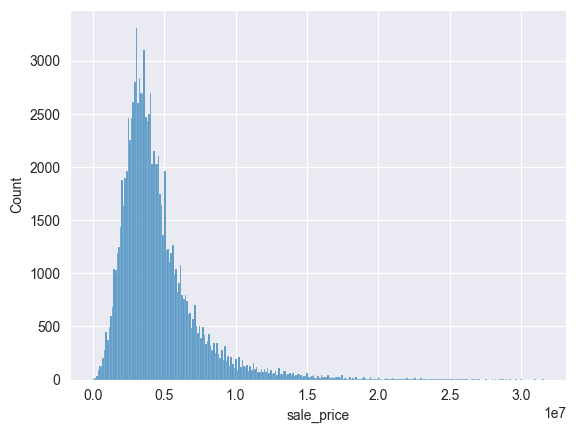

In [9]:
sns.histplot(df,x = "sale_price")

In [5]:
a = bq.read_bq("""SELECT * FROM `sibr-market.staging.cadastrals`
WHERE active = TRUE""")

In [7]:
a.duplicated(subset  =["item_id"]).sum()

np.int64(0)

In [2]:
logger = Logger("kartverketMain")
secret = SecretsManager(logger = logger,project_id="sibr-market")
api_key = secret.get_secret("GRUNNBOK_API_KEY")
if api_key:
    os.environ["GRUNNBOK_USERNAME"] = "sibrprod"
    os.environ["GRUNNBOK_PASSWORD"] = api_key
else:
    raise PermissionError("No API key found")
api = kartverketsAPI(logger=logger)

2025-09-16 09:40:56,260 - kartverketMain - INFO - Cloud Logging is disabled. Using local logging to /Users/sigvardbratlie/PycharmProjects/sibr-market-backend/logfiles/kartverketMain.log.
2025-09-16 09:40:56,343 - kartverketMain - INFO - SecretsManager initialized.
2025-09-16 09:40:56,864 - kartverketMain - INFO - Read in secret: GRUNNBOK_API_KEY from project sibr-market


In [3]:
prop  = {
        "kommunenummer": "3212",
        "gaardsnummer": 1,
        "bruksnummer": 2,
        "festenummer": 0,
        "seksjonsnummer": 0
    },

In [7]:
res = await api.get_by_property([prop],transfer_type = "active")

2025-09-16 09:43:01,405 - kartverketMain - INFO - 🔢  Fetching property ids for 1 properties with ownership type eier


TypeError: MatrikkelenhetIdent({http://kartverket.no/grunnbok/wsapi/v2/domain/grunnboksidenter}MatrikkelenhetIdent(kommunenummer: xsd:string, gaardsnummer: xsd:int, bruksnummer: xsd:int, festenummer: xsd:int, seksjonsnummer: xsd:int)) argument after ** must be a mapping, not tuple

In [5]:
res

<coroutine object kartverketsAPI.get_by_property at 0x10587bac0>